# Bank Credit Card Churn Prediction
## Modeling

I build machine learning models to predict customer churn, evaluate their performance, and identify the most important 
factors driving churn. I use results from EDA, use feature selection, handle class imbalance with SMOTE and compare multiple models 
to find the best one.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from imblearn.over_sampling import SMOTE
import shap

### PART 1: Data Preprocessing

In [2]:
df = pd.read_csv('BankChurners.csv')
df = df.iloc[:,:-2]
df['Churn'] =(df['Attrition_Flag']=='Attrited Customer').astype(int)
df = df.drop(['CLIENTNUM','Attrition_Flag'], axis=1)
# Drop Avg_Open_To_Buy - highly correlated with Credit_Limit
df = df.drop('Avg_Open_To_Buy', axis=1)

In [3]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
le =LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"shape after encoding: {df.shape}")
df.head()

shape after encoding: (10127, 19)


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061,0
1,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105,0
2,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000,0
3,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,0
4,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,2.175,816,28,2.500,0.000,0


### PART 2: Feature Selection

I select the most relevant features based on EDA.

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used for modeling:")
for col in X.columns:
    print(f"  -{col}")

Features shape: (10127, 18)
Target shape: (10127,)

Features used for modeling:
  -Customer_Age
  -Gender
  -Dependent_count
  -Education_Level
  -Marital_Status
  -Income_Category
  -Card_Category
  -Months_on_book
  -Total_Relationship_Count
  -Months_Inactive_12_mon
  -Contacts_Count_12_mon
  -Credit_Limit
  -Total_Revolving_Bal
  -Total_Amt_Chng_Q4_Q1
  -Total_Trans_Amt
  -Total_Trans_Ct
  -Total_Ct_Chng_Q4_Q1
  -Avg_Utilization_Ratio


### PART 3: Train Test Split

I split the data into 80% training and 20% test sets. I do it before SMOTE to prevent data leakage.

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"training set:")
print(y_train.value_counts())
print(f" test set:")
print(y_test.value_counts())

Training set: 8101 rows
Test set: 2026 rows
training set:
Churn
0    6799
1    1302
Name: count, dtype: int64
 test set:
Churn
0    1701
1     325
Name: count, dtype: int64


### PART 4: Handling Class Imbalance with SMOTE

16% churn rate means significant class imbalance.
I use SMOTE which creates synthetic samples of churned customers to balance the dataset.
it is applied only on training data to prevent data leakage.
Applying SMOTE before splitting would cause fake data to leak into test set and it woould make evaluation results unrealistic.

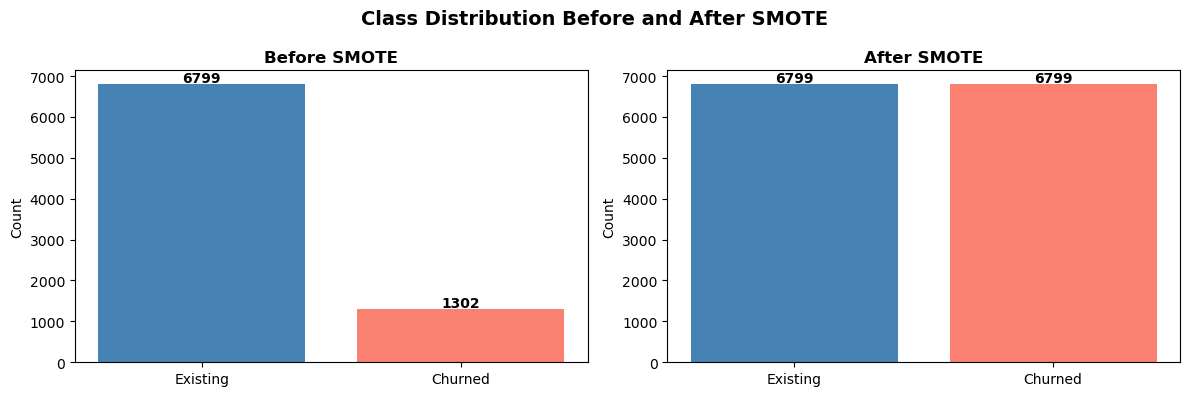

In [6]:
smote = SMOTE(random_state =42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(['Existing','Churned'], [sum(y_train==0),sum(y_train==1)], color=['steelblue','salmon'])
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i,v in enumerate([sum(y_train==0), sum(y_train==1)]):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

axes[1].bar(['Existing','Churned'], [sum(y_train_res==0), sum(y_train_res==1)], color=['steelblue','salmon'])
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
for i,v in enumerate([sum(y_train_res==0),sum(y_train_res==1)]):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/smote_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 5: Model Building

I build four models:
1. Logistic Regression — simple baseline model
2. Decision Tree — interpretable tree based model  
3. Random Forest — ensemble model
4. XGBoost — advanced gradient boosting model

Each model is evaluated using: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

In [7]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy  = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall =recall_score(y_test,y_pred)
    f1= f1_score(y_test,y_pred)

    print(f"{model_name}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
    print(f"Recall: {recall:.4f} ({recall*100:.1f}%)")
    print(f"F1-Score: {f1:.4f} ({f1*100:.1f}%)")
    print(f"Classification Report:")
    print(classification_report(y_test,y_pred, target_names=['Existing','Churned']))
    return {'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1}
    

#### 5.1 Logistic Regression

C:\Users\Meri\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.8272 (82.7%)
Precision: 0.4762 (47.6%)
Recall: 0.7692 (76.9%)
F1-Score: 0.5882 (58.8%)
Classification Report:
              precision    recall  f1-score   support

    Existing       0.95      0.84      0.89      1701
     Churned       0.48      0.77      0.59       325

    accuracy                           0.83      2026
   macro avg       0.71      0.80      0.74      2026
weighted avg       0.87      0.83      0.84      2026



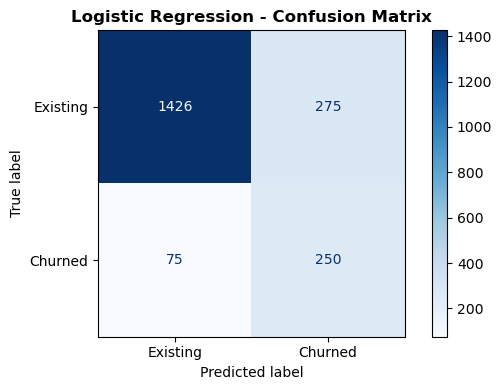

In [8]:
lr = LogisticRegression(random_state=42,max_iter=1000)
lr.fit(X_train_res,y_train_res)
lr_metrics = evaluate_model(lr, X_test, y_test, "Logistic Regression")

fig,ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, display_labels=['Existing','Churned'], cmap='Blues', ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.2 Decision Tree

Decision Tree splits data based on feature values to create a 
tree of decisions. I limit max_depth=6 to prevent overfitting

Decision Tree
Accuracy: 0.9195 (92.0%)
Precision: 0.6985 (69.9%)
Recall: 0.8769 (87.7%)
F1-Score: 0.7776 (77.8%)
Classification Report:
              precision    recall  f1-score   support

    Existing       0.98      0.93      0.95      1701
     Churned       0.70      0.88      0.78       325

    accuracy                           0.92      2026
   macro avg       0.84      0.90      0.86      2026
weighted avg       0.93      0.92      0.92      2026



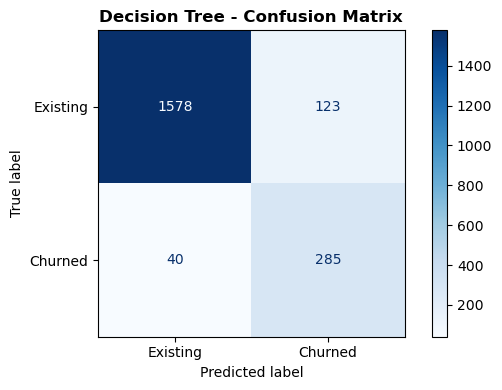

In [9]:
dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train_res,y_train_res)
dt_metrics = evaluate_model(dt, X_test, y_test, "Decision Tree")

fig,ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(dt,X_test,y_test, display_labels=['Existing','Churned'], cmap='Blues', ax=ax)
ax.set_title('Decision Tree - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cm_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.3 Random Forest

Random Forest builds multiple decision trees independently and 
combines their predictions through voting, so this reduces overfitting 

Random Forest
Accuracy: 0.9536 (95.4%)
Precision: 0.8448 (84.5%)
Recall: 0.8708 (87.1%)
F1-Score: 0.8576 (85.8%)
Classification Report:
              precision    recall  f1-score   support

    Existing       0.98      0.97      0.97      1701
     Churned       0.84      0.87      0.86       325

    accuracy                           0.95      2026
   macro avg       0.91      0.92      0.91      2026
weighted avg       0.95      0.95      0.95      2026



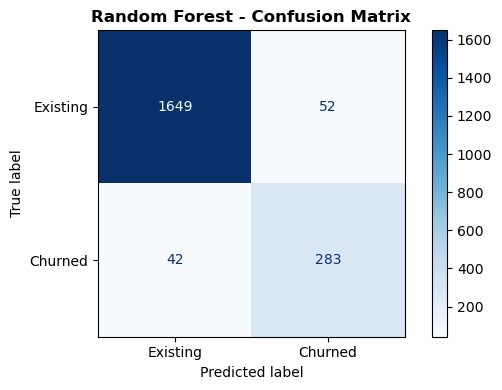

In [10]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_res, y_train_res)
rf_metrics = evaluate_model(rf, X_test,y_test, "Random Forest")

fig,ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=['Existing','Churned'], cmap='Blues', ax=ax)
ax.set_title('Random Forest - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.4 XGBoost

XGBoost builds trees sequentially where each tree learns from and corrects the errors of the previous one. 

XGBoost
Accuracy: 0.9684 (96.8%)
Precision: 0.9040 (90.4%)
Recall: 0.8985 (89.8%)
F1-Score: 0.9012 (90.1%)
Classification Report:
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
     Churned       0.90      0.90      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



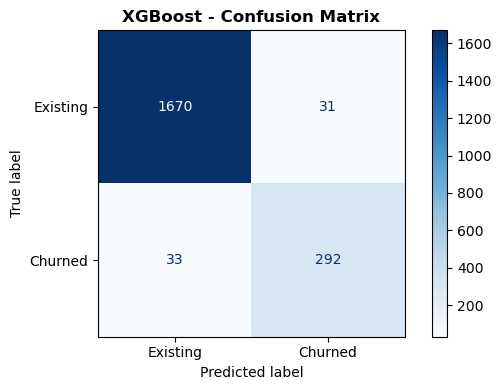

In [11]:
xgb = XGBClassifier(random_state=42,eval_metric='logloss',n_estimators=100)
xgb.fit(X_train_res,y_train_res)
xgb_metrics =evaluate_model(xgb, X_test, y_test, "XGBoost")

fig,ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, display_labels=['Existing','Churned'], cmap='Blues', ax=ax)
ax.set_title('XGBoost - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cm_xgboost.png',dpi=150, bbox_inches='tight')
plt.show()

### PART 6: Model Comparison

I compare all four models side by side to identify the best performing model.

In [12]:
results = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics])
results = results.set_index('Model')
results = results.round(4)

print("Model comparison (Before Tuning)")
print(results)

Model comparison (Before Tuning)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8272     0.4762  0.7692    0.5882
Decision Tree          0.9195     0.6985  0.8769    0.7776
Random Forest          0.9536     0.8448  0.8708    0.8576
XGBoost                0.9684     0.9040  0.8985    0.9012


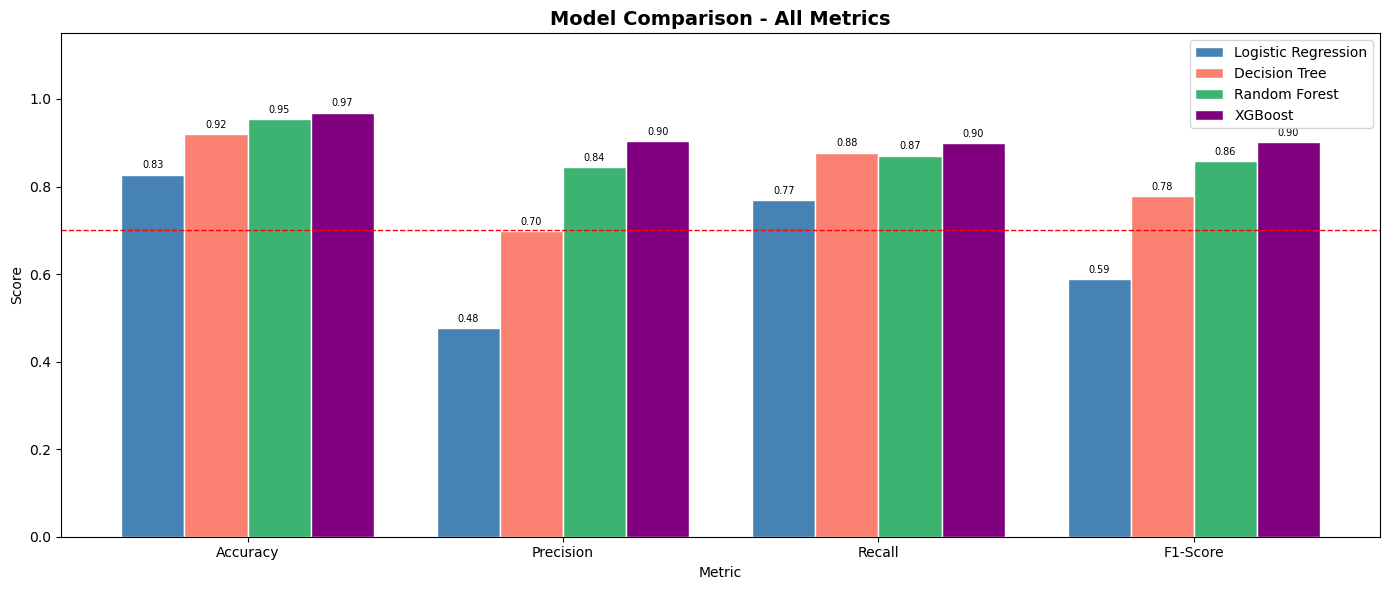

In [13]:
metrics = ['Accuracy','Precision','Recall','F1-Score']
x =np.arange(4)
width = 0.2
fig,ax = plt.subplots(figsize=(14,6))

bars1= ax.bar(x-width*1.5, results.loc['Logistic Regression',metrics],
                width, label='Logistic Regression', color='steelblue', edgecolor='white')
bars2= ax.bar(x-width*0.5, results.loc['Decision Tree',metrics],
               width, label='Decision Tree', color='salmon', edgecolor='white')
bars3= ax.bar(x+width*0.5, results.loc['Random Forest',metrics],
               width, label='Random Forest', color='mediumseagreen', edgecolor='white')
bars4= ax.bar(x+width*1.5, results.loc['XGBoost',metrics],
               width, label='XGBoost', color='purple', edgecolor='white')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0,1.15)
ax.axhline(y=0.7, color='red', linestyle='--', linewidth=1, label='70% target')

for bars in [bars1,bars2,bars3,bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2., height+0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 7: Hyperparameter Tuning

I tune the two best performing models — Random Forest and XGBoost.

#### 7.1 Random Forest Hyperparameter Tuning

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 score (cross validation): 0.9792
Random Forest (Tuned)
Accuracy: 0.9531 (95.3%)
Precision: 0.8443 (84.4%)
Recall: 0.8677 (86.8%)
F1-Score: 0.8558 (85.6%)
Classification Report:
              precision    recall  f1-score   support

    Existing       0.97      0.97      0.97      1701
     Churned       0.84      0.87      0.86       325

    accuracy                           0.95      2026
   macro avg       0.91      0.92      0.91      2026
weighted avg       0.95      0.95      0.95      2026



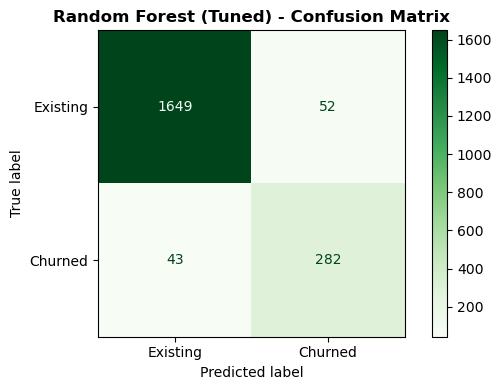

In [14]:
rf_param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10,20,None],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1)

rf_grid.fit(X_train_res, y_train_res)

print(f"\nBest Random Forest parameters: {rf_grid.best_params_}")
print(f"Best F1 score (cross validation): {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
best_rf_metrics = evaluate_model(best_rf,X_test,y_test,"Random Forest (Tuned)")
fig,ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels=['Existing','Churned'], cmap='Greens', ax=ax)

ax.set_title('Random Forest (Tuned) - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cm_rf_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

#### 7.2 XGBoost Hyperparameter Tuning

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best F1 score (cross validation): 0.9804
XGBoost (Tuned)
Accuracy: 0.9679 (96.8%)
Precision: 0.9012 (90.1%)
Recall: 0.8985 (89.8%)
F1-Score: 0.8998 (90.0%)
Classification Report:
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
     Churned       0.90      0.90      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



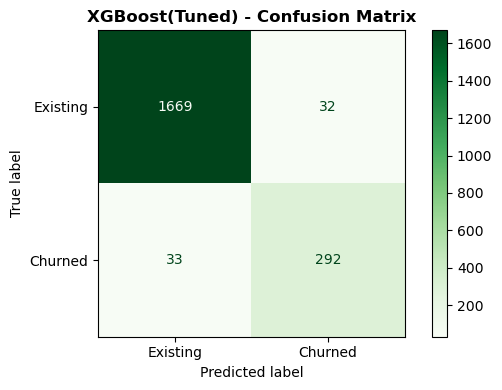

In [15]:
xgb_param_grid = {
    'n_estimators': [100,200],
    'max_depth': [3,5,7],
    'learning_rate': [0.01,0.1],
    'subsample': [0.8,1.0]}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42,eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1)
xgb_grid.fit(X_train_res,y_train_res)

print(f"\nBest XGBoost parameters: {xgb_grid.best_params_}")
print(f"Best F1 score (cross validation): {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_
best_xgb_metrics = evaluate_model(best_xgb, X_test, y_test, "XGBoost (Tuned)")
fig,ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=['Existing','Churned'], cmap='Greens', ax=ax)

ax.set_title('XGBoost(Tuned) - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cm_xgb_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

#### 7.3 Cross Validation

Random Forest (Tuned):
CV Scores: [0.9612 0.9804 0.9833 0.9837 0.9876]
Mean F1: 0.9792
Std: 0.0093

XGBoost (Tuned):
CV Scores: [0.9516 0.9858 0.9862 0.9876 0.9887]
Mean F1: 0.9800
Std: 0.0142



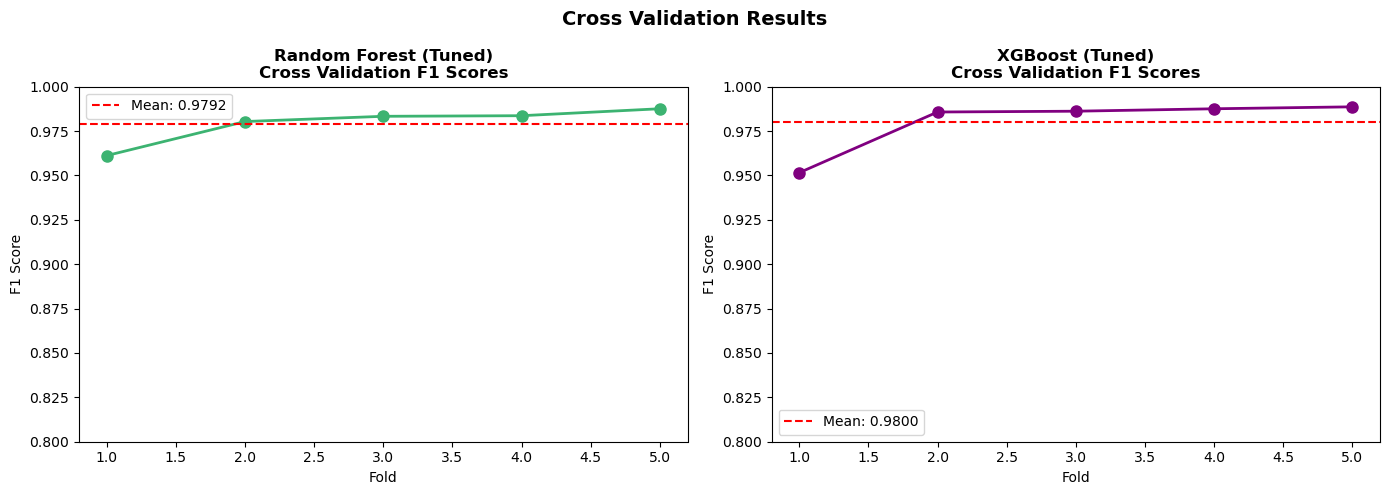

In [16]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

for ax,model,name,color in zip(
    axes,[best_rf,best_xgb],
    ['Random Forest (Tuned)','XGBoost (Tuned)'],
    ['mediumseagreen','purple']):
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='f1')
    ax.plot(range(1,6), cv_scores, marker='o', color=color, linewidth=2, markersize=8)
    ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
    ax.set_title(f'{name}\nCross Validation F1 Scores', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0.8,1.0)
    ax.legend()
    print(f"{name}:")
    print(f"CV Scores: {cv_scores.round(4)}")
    print(f"Mean F1: {cv_scores.mean():.4f}")
    print(f"Std: {cv_scores.std():.4f}\n")

plt.suptitle('Cross Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 8: ROC Curve Comparison

ROC curve shows the tradeoff between catching real churners and incorrectly flagging existing customers as churners.

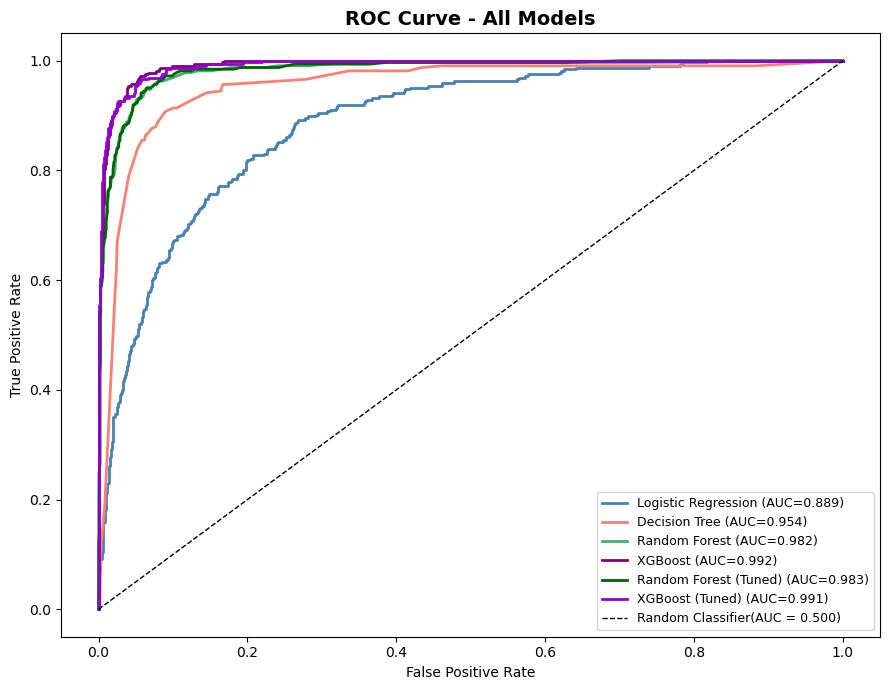

In [17]:
fig,ax = plt.subplots(figsize=(9,7))

models_roc = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Random Forest (Tuned)':best_rf,
    'XGBoost (Tuned)': best_xgb}

colors_roc = ['steelblue', 'salmon', 'mediumseagreen', 'purple', 'darkgreen', 'darkviolet']

for (name,model), color in zip(models_roc.items(),colors_roc):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr,tpr, _ = roc_curve(y_test,y_prob)
    roc_auc = auc(fpr,tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier(AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 9: Feature Importance Analysis

I analyze which features had the most impact on churn using Built-in Feature Importance and SHAP Values.

#### 9.1 Feature Importance Comparison

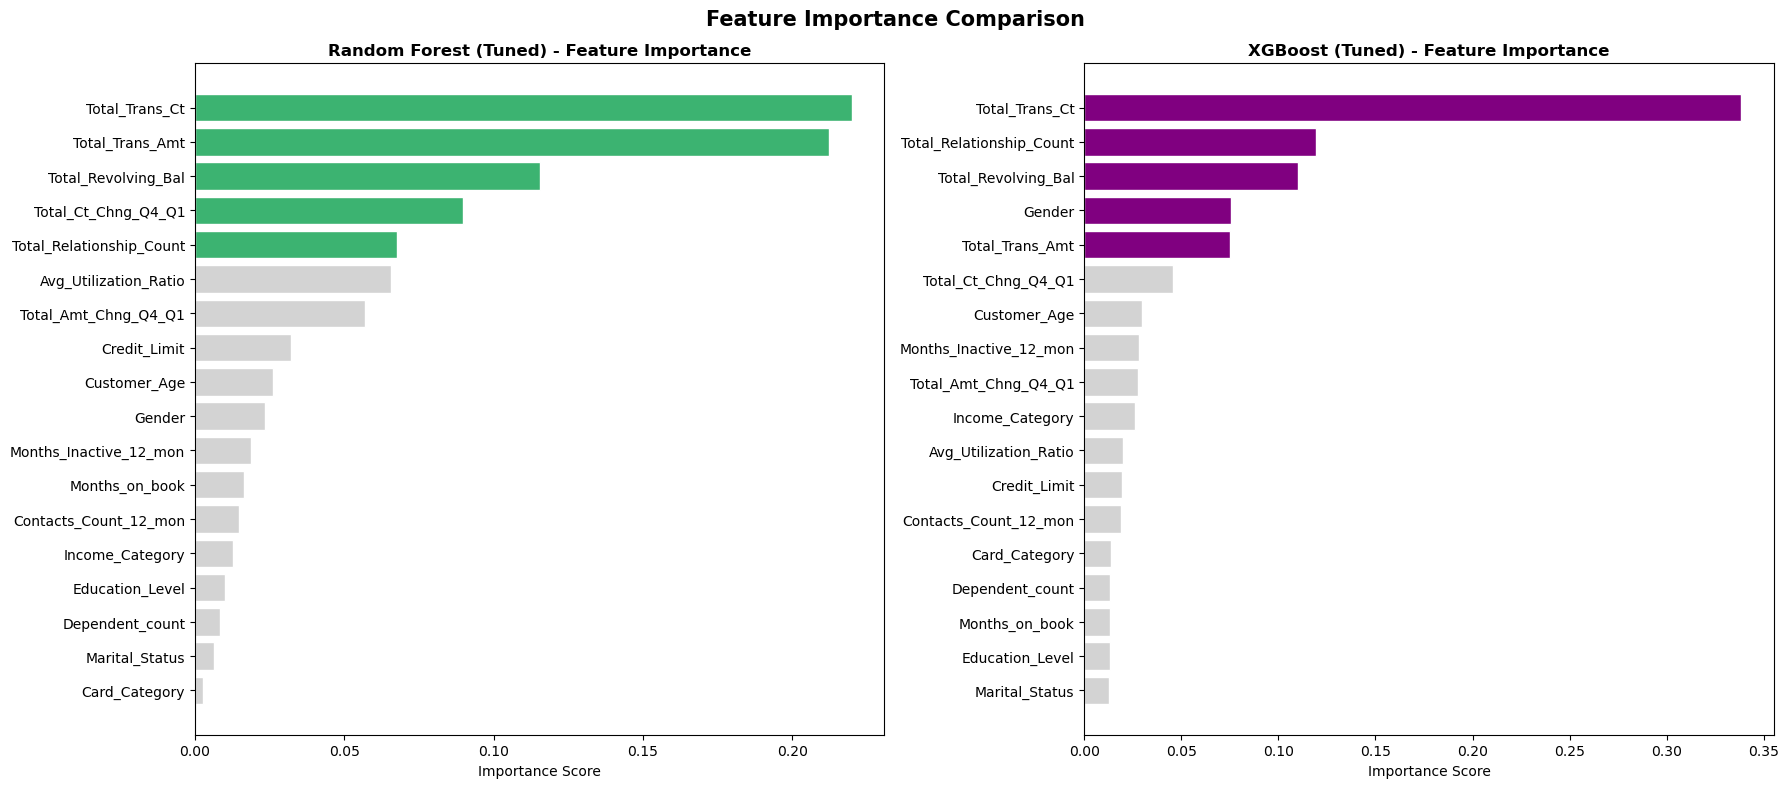

Top 5 Features (Random Forest Tuned):
                     Feature  Importance
15            Total_Trans_Ct    0.219784
14           Total_Trans_Amt    0.212258
12       Total_Revolving_Bal    0.115395
16       Total_Ct_Chng_Q4_Q1    0.089833
8   Total_Relationship_Count    0.067794
Top 5 Features (XGBoost Tuned):
                     Feature  Importance
15            Total_Trans_Ct    0.338264
8   Total_Relationship_Count    0.119199
12       Total_Revolving_Bal    0.110077
1                     Gender    0.075475
14           Total_Trans_Amt    0.074879


In [18]:
fig,axes = plt.subplots(1,2,figsize=(18,8))

for ax,model,name,color in zip(
    axes,
    [best_rf,best_xgb],
    ['Random Forest (Tuned)','XGBoost (Tuned)'],
    ['mediumseagreen','purple']):
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature':X.columns,
        'Importance':importances
    }).sort_values('Importance',ascending=True)

    colors_bar = [color if i >= len(importance_df)-5
                  else 'lightgray'
                  for i in range(len(importance_df))]

    ax.barh(importance_df['Feature'],importance_df['Importance'],color=colors_bar, edgecolor='white')
    ax.set_title(f'{name} - Feature Importance',fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Features (Random Forest Tuned):")
rf_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance',ascending=False)
print(rf_imp.head())

print("Top 5 Features (XGBoost Tuned):")
xgb_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance',ascending=False)
print(xgb_imp.head())

#### 9.2 SHAP Values

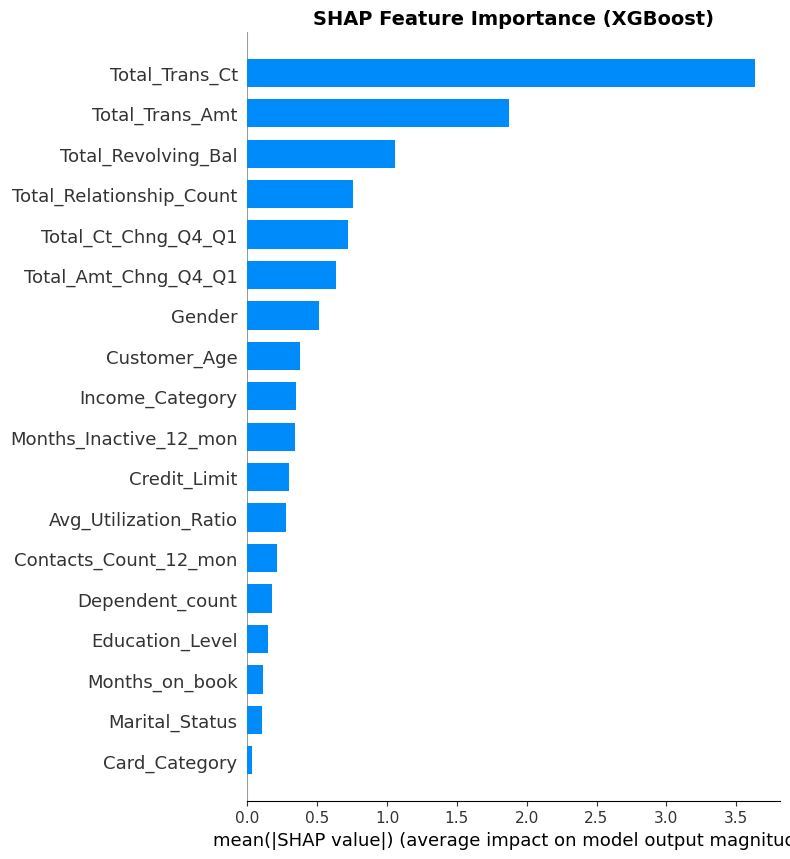

In [19]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

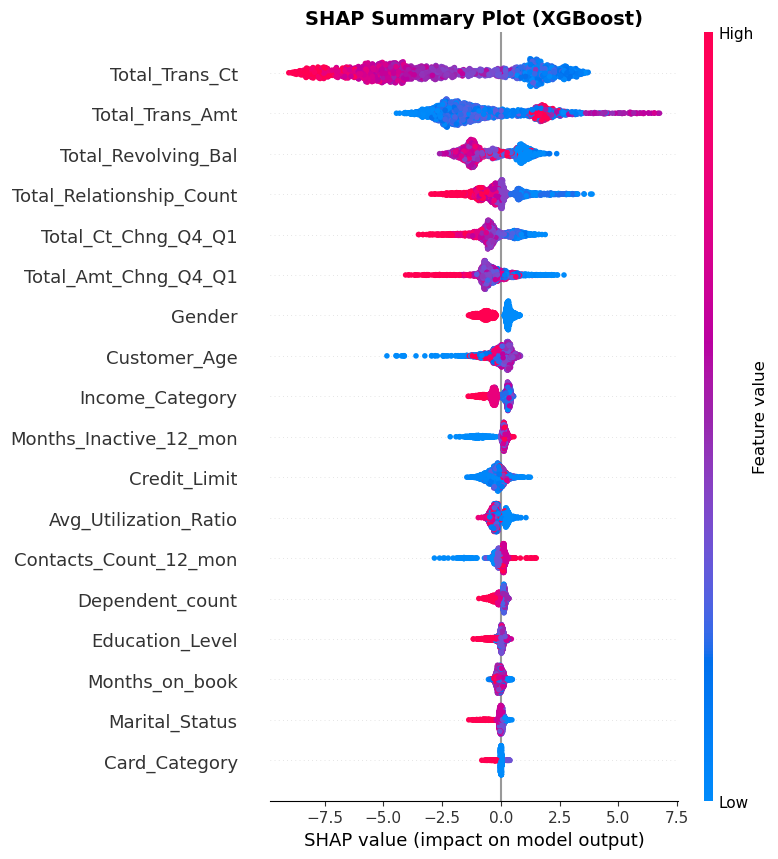

In [20]:
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 10: Final Results and Conclusions

#### 10.1 Final Model Comparison

In [21]:
final_results = pd.DataFrame([lr_metrics,dt_metrics,rf_metrics,xgb_metrics,best_rf_metrics,best_xgb_metrics])
final_results = final_results.set_index('Model').round(4)

print("Final Model Comparison")
print(final_results)

best_model_name = final_results['F1-Score'].idxmax()
best_f1 = final_results['F1-Score'].max()
print(f"Best Model: {best_model_name}")
print(f"Best F1-Score: {best_f1:.4f} ({best_f1*100:.1f}%)")
print(f"All models exceed the 70% accuracy and F1-score target")

Final Model Comparison
                       Accuracy  Precision  Recall  F1-Score
Model                                                       
Logistic Regression      0.8272     0.4762  0.7692    0.5882
Decision Tree            0.9195     0.6985  0.8769    0.7776
Random Forest            0.9536     0.8448  0.8708    0.8576
XGBoost                  0.9684     0.9040  0.8985    0.9012
Random Forest (Tuned)    0.9531     0.8443  0.8677    0.8558
XGBoost (Tuned)          0.9679     0.9012  0.8985    0.8998
Best Model: XGBoost
Best F1-Score: 0.9012 (90.1%)
All models exceed the 70% accuracy and F1-score target


#### 10.2 Modeling Conclusions

After building and evaluating four machine learning models, I can conclude that the results were very positive and exceeded my initial expectations. All models achieved accuracy and F1-scores above the target of 70%, showing that machine learning can be successfully used to predict customer churn in the banking sector.

**Model Performance**

Each model performed differently and had its own strengths.

Logistic Regression was the weakest model among the four, but it still provided a useful baseline. It was able to identify some churn patterns, although its performance was limited because it assumes mostly linear relationships between variables.

Decision Tree performed better than Logistic Regression. By allowing non-linear decision rules, it captured more complex patterns in customer behavior. Limiting the maximum depth helped reduce overfitting, but the model was still less accurate than the ensemble methods.

Random Forest showed a noticeable improvement in performance. Since it combines the predictions of many decision trees, it was able to make more reliable predictions and reduce the risk of overfitting. The model also highlighted several important customer behavior variables related to churn.

XGBoost achieved the best overall performance with approximately 96.8% accuracy and 90.1% F1-score. Its boosting approach, where each new tree learns from the mistakes of previous trees, proved to be very effective for this dataset. Based on the evaluation metrics, XGBoost was selected as the final model for this project.

Regarding hyperparameter tuning I found out that the tuned XGBoost actually performed almost identically to the default version with only a 0.001 difference in F1-score. This suggests that XGBoost default parameters are already well suited for this type of banking data. I still kept the tuned version for feature importance and SHAP analysis as it represents the optimized model.

**Most Important Churn Factors**

Feature importance and SHAP analysis produced very similar results, which increases confidence in the findings.

The most important factors affecting churn were:

1. **Total_Trans_Ct** – the total number of transactions made by a customer. This was by far the strongest predictor. Customers who used their credit cards less frequently were much more likely to leave the bank.

2. **Total_Trans_Amt** – the total amount spent using the credit card. Lower spending was associated with a higher risk of churn.

3. **Total_Revolving_Bal** – the revolving balance on the card. Customers with lower balances appeared to be less engaged and therefore more likely to churn.

4. **Total_Relationship_Count** – the number of banking products used by a customer. Customers who used multiple products were generally more loyal and less likely to leave.

5. **Total_Ct_Chng_Q4_Q1** – the change in transaction count over time. A decrease in transaction activity was an important warning sign that a customer might churn.

The SHAP summary plot provided additional insight into how these variables affected the predictions. In particular, lower transaction counts, fewer banking relationships, and declining transaction activity were strongly associated with higher churn risk.

What I found especially interesting was that these results closely matched the patterns discovered during the exploratory data analysis stage. This consistency suggests that the findings are meaningful and not simply the result of random patterns in the data.

**Importance of SMOTE**

The dataset was imbalanced, with existing customers making up around 84% of the observations and churned customers only 16%.

Without SMOTE, the models would tend to predict the majority class most of the time, leading to high accuracy but poor identification of churned customers. By balancing the training data, SMOTE helped the models learn the characteristics of churned customers more effectively and improved recall.

This was particularly important because, from a business perspective, failing to identify a customer who is likely to leave is usually more costly than incorrectly flagging a customer who would have stayed.

#### 10.3 Business Recommendations

Based on the findings from the exploratory data analysis and machine learning models, I would recommend the following actions:

1. **Implement an early warning system.** The XGBoost model could be used to identify customers who are at high risk of churn so that the bank can take action before they leave.

2. **Monitor transaction activity.** Since transaction count was the strongest predictor of churn, customers whose activity decreases significantly should be flagged for review.

3. **Target customers with declining spending.** Customers who are spending less than usual may be losing interest in the bank's services and could benefit from personalized offers or rewards.

4. **Encourage customers to use multiple products.** Customers with more banking products were less likely to churn, suggesting that stronger customer relationships improve loyalty.

5. **Contact customers showing signs of disengagement.** A decline in transaction activity over time can act as an early warning signal and should trigger proactive communication.

6. **Focus on low-engagement customers.** Customers with low transaction activity and low revolving balances appear to be at higher risk and may require additional retention efforts.

Overall, this project demonstrated that machine learning can be a valuable tool for predicting customer churn. Among the models tested, XGBoost achieved the best results and provided highly accurate predictions. The analysis also showed that customer engagement indicators, especially transaction behavior and product usage, play a major role in predicting whether a customer is likely to leave the bank. By using these insights, banks can identify at-risk customers earlier and develop more effective retention strategies.
